# Vorlesung: Datenanalyse in Energiesystemen
## Übung: Wöchentliches Lastprofil-Clustering (Mean vs. Medoid)

**Lernziele dieser Pipeline:**
1. **Datenakquisition & Bereinigung:** Filtern von Sensor-Daten und Entfernung von Ausreißern mittels statistischer Methoden ($Z$-Score).
2. **Feature Engineering / Domänenwissen:** Implementierung eines Feiertags-Algorithmus, da sich Lastprofile an Feiertagen wie Sonntage verhalten.
3. **Aggregations- & Clustering-Methoden:** Mathematischer Vergleich zwischen dem klassischen **Mittelwert (Mean)** und dem **Zentralwert (Medoid)** zur Erstellung von Referenz-Lastprofilen.

---

### Schritt 1: Vorbereitung der Google Colab Umgebung
Da wir uns in einer Cloud-Umgebung befinden, müssen wir zuerst die benötigten Bibliotheken (`Lastgang.csv`) importieren. Diese stammt aus dem Monitoring eines Gewerbegebäudes (Büros und Werkstatt)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

print("Importiere Lastgang:")
drive_path = "/content/drive/MyDrive/Colab Notebooks/Lastgang.csv"
datei_name = 'Lastgang.csv'

if os.path.exists(drive_path):
    df_last = pd.read_csv(drive_path)
    print("Datei 'Lastgang.csv' aus dem Drive geladen!")
else:
    print("Datei nicht im Drive gefunden.")
    print("Bitte lade die 'Lastgang.csv' manuell hoch:")

    uploaded = files.upload()
    fname = list(uploaded.keys())[0]

    # In den Speicher lesen für die sofortige Nutzung
    df_last = pd.read_csv(io.BytesIO(uploaded[fname]))

    # Dauerhaft ins Drive kopieren
    import shutil
    # Sicherstellen, dass das Verzeichnis existiert
    os.makedirs(os.path.dirname(drive_path), exist_ok=True)

    with open(drive_path, 'wb') as f:
        f.write(uploaded[fname])

    print(f"Datei wurde nach '{drive_path}' kopiert und ist nun dauerhaft verfügbar.")

# Parameter-Konfiguration
SENSOR_ID = 23
WEEKS_BACK = 8  # Anzahl der vollen Wochen, die analysiert werden sollen
Z_THRESHOLD = 2.5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Importiere Lastgang:
Datei 'Lastgang.csv' aus dem Drive geladen!


### Schritt 2: Einbinden von Domänenwissen (Feiertagslogik)
In der Energiewirtschaft hängen Lastprofile stark vom menschlichen Verhalten ab. Wir treffen hier die Annahme, dass sich ein gesetzlicher Feiertag unter der Woche tendenziell wie ein **Sonntag** verhält.

Hier nutzen wir den **Meeus/Jones/Butcher-Algorithmus**, um das Datum des Ostersonntags mathematisch zu berechnen. Davon ausgehend bestimmen wir die beweglichen deutschen Feiertage (z. B. Karfreitag, Ostermontag, Christi Himmelfahrt, Pfingstmontag, Fronleichnam).

In [ ]:
def get_easter_sunday(year):
    """Berechnet den Ostersonntag für ein gegebenes Jahr."""
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451

    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(year, month, day)

def is_german_holiday(dt):
    """Prüft, ob ein gegebenes Datum ein bundeseinheitlicher Feiertag ist."""
    if (dt.month == 1 and dt.day == 1): return True
    if (dt.month == 1 and dt.day == 6): return True
    if (dt.month == 5 and dt.day == 1): return True
    if (dt.month == 10 and dt.day == 3): return True
    if (dt.month == 11 and dt.day == 1): return True
    if (dt.month == 12 and dt.day == 25): return True
    if (dt.month == 12 and dt.day == 26): return True

    easter = get_easter_sunday(dt.year)
    if dt == (easter - pd.Timedelta(days=2)): return True # Karfreitag
    if dt == (easter + pd.Timedelta(days=1)): return True # Ostermontag
    if dt == (easter + pd.Timedelta(days=39)): return True # Christi Himmelfahrt
    if dt == (easter + pd.Timedelta(days=50)): return True # Pfingstmontag
    if dt == (easter + pd.Timedelta(days=60)): return True # Fronleichnam
    return False

### Schritt 3: Mathematische Glättung (Gleitender Mittelwert)
Um hochfrequentes Rauschen aus den Profilen zu entfernen, implementieren wir einen **Moving Average** (Gleitenden Mittelwert). Dies hilft, die grundlegenden Trends der Energiekurve deutlicher hervorzuheben.

In [ ]:
def moving_average_week(data, window):
    """Glättet ein Array mithilfe eines gleitenden Mittelwerts."""
    if window <= 1:
        return data.copy()
    out = np.zeros_like(data)
    half = window // 2
    n = len(data)
    for i in range(n):
        start = max(0, i - half)
        end = min(n, i + half + 1)
        out[i] = np.mean(data[start:end])
    return out

### Schritt 4: Datenvorverarbeitung

- **Selektion und zeitliche Eingrenzung**
  - Es werden ausschließlich die relevanten Daten der definierten `SENSOR_ID` extrahiert.
  - Der Code berechnet dynamisch den Zeitraum der letzten `WEEKS_BACK` Wochen.
  - Dabei wird sichergestellt, dass das Zeitfenster stets an einem **Montag beginnt** und an einem **Sonntag endet**.
  - Dieser *Full-Week-Ansatz* ist essenziell, da unvollständige Wochenzyklen zu Verzerrungen im Modell führen können.

---

- **Standardisierung der Zeitachse (Resampling)**
  - Mittels `groupby()` und `resample('1T')` werden die Sensordaten auf ein festes **1-Minuten-Raster** gebracht.
  - Da Sensordaten häufig unregelmäßig eintreffen oder Lücken enthalten, wird dadurch eine konsistente Zeitachse erzeugt.
  - Fehlende Zeitpunkte werden mit `ffill()` (*Forward Fill*) durch den zuletzt verfügbaren Messwert ersetzt.
  - Dieses Verfahren wird auch als *Last Observation Carried Forward (LOCF)* bezeichnet.
  - Dadurch bleibt der Datenstrom lückenlos und für die weitere Analyse geeignet.

---

- **Statistische Ausreißerbereinigung mittels Z-Score**
  - Zur Glättung von Messfehlern und extremen Ausreißern wird eine statistische Bereinigung durchgeführt.
  - Für jede Kombination aus Wochentag und Uhrzeit (z. B. *Montag, 10:00 Uhr*) werden folgende Kennwerte berechnet:
    - Mittelwert $\mu$
    - Standardabweichung $\sigma$

  - Die Abweichung eines Messwertes vom erwarteten Verhalten wird über den Z-Score bestimmt:

  $$
  Z = \frac{x - \mu}{\sigma}
  $$

  wobei

  - $x$ = aktueller Messwert
  - $\mu$ = Mittelwert der entsprechenden Stunde
  - $\sigma$ = Standardabweichung der entsprechenden Stunde

  - Ein Messwert wird als Ausreißer klassifiziert, wenn gilt:

  $$
  |Z| > Z_{\text{THRESHOLD}}
  $$

  - Im vorliegenden Fall wird verwendet:

  $$
  Z_{\text{THRESHOLD}} = 2.5
  $$

  - Erkannte Ausreißer werden anschließend durch den statistischen Mittelwert der entsprechenden Stunde ersetzt:

  $$
  x_{\text{neu}} = \mu
  $$

  - Dadurch bleibt die Zeitreihe konsistent, während extreme Fehlmessungen die spätere Optimierung nicht verfälschen.

---

- **Hinweis**
  - Die Qualität der Eingangsdaten bestimmt maßgeblich die Güte der späteren Prognose.
  - In praktischen Data-Science- und Machine-Learning-Projekten wird häufig mehr Zeit für die Datenbereinigung (*Data Cleaning*) aufgewendet als für die Entwicklung des eigentlichen Algorithmus.
  - Eine saubere und konsistente Zeitreihe bildet die Grundlage für valide und belastbare Ergebnisse der nachfolgenden Optimierung.

In [ ]:
def load_data_variants():

    print(f"--> Lade Daten")
    df_raw = df_last
    df_raw = df_raw[df_raw['sensor_id'] == SENSOR_ID].copy()

    if df_raw.empty:
        print(f"Warnung: Keine Daten für Sensor ID {SENSOR_ID} gefunden.")
        return pd.DataFrame(), pd.DataFrame()

    df_raw['datetime'] = pd.to_datetime(df_raw['timestamp'], unit='s')

    # Zeitfenster für exakt die letzten X vollen Kalenderwochen bestimmen
    now = pd.Timestamp.now().normalize()
    days_to_sunday = now.weekday() + 1
    end_dt = now - pd.Timedelta(days=days_to_sunday) + pd.Timedelta(hours=23, minutes=59, seconds=59)
    start_dt = (end_dt - pd.Timedelta(weeks=WEEKS_BACK)).normalize() + pd.Timedelta(days=1)

    print(f"--> Analyse-Zeitfenster:\n    Von: {start_dt} (Mo)\n    Bis: {end_dt} (So)")
    df_raw = df_raw[(df_raw['datetime'] >= start_dt) & (df_raw['datetime'] <= end_dt)]

    df_grouped = df_raw.groupby('datetime')['value'].sum().to_frame()

    # Ungefilterte Basis (1-Minuten-Resampling)
    df_unfiltered = df_grouped.resample('1T').ffill()
    df_unfiltered['timestamp'] = df_unfiltered.index
    df_unfiltered.reset_index(drop=True, inplace=True)

    # Gefilterte Zeitreihe (Z-Score-Bereinigung)
    df_filtered = df_unfiltered.copy()
    df_filtered['weekday'] = df_filtered['timestamp'].dt.weekday
    df_filtered['hour'] = df_filtered['timestamp'].dt.hour

    stats = df_filtered.groupby(['weekday', 'hour'])['value'].agg(['mean', 'std']).reset_index()
    df_filtered = df_filtered.merge(stats, on=['weekday', 'hour'], how='left')
    df_filtered['std'] = df_filtered['std'].replace(0, 1e-6)
    df_filtered['z_score'] = (df_filtered['value'] - df_filtered['mean']) / df_filtered['std']

    outliers_mask = df_filtered['z_score'].abs() > Z_THRESHOLD
    print(f"--> Outlier Detection: {outliers_mask.sum()} Ausreißer-Minuten bereinigt.")

    df_filtered.loc[outliers_mask, 'value'] = df_filtered.loc[outliers_mask, 'mean']
    df_filtered = df_filtered[['timestamp', 'value']]

    return df_filtered, df_unfiltered[['timestamp', 'value']]

###Schritt 5.1: Plot Vergleich Rohdaten vs. bereinigte Daten

--> Lade Daten
--> Analyse-Zeitfenster:
    Von: 2026-04-13 00:00:00 (Mo)
    Bis: 2026-06-07 23:59:59 (So)


/tmp/ipykernel_2812/4060617816.py:25: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_unfiltered = df_grouped.resample('1T').ffill()


--> Outlier Detection: 1553 Ausreißer-Minuten bereinigt.


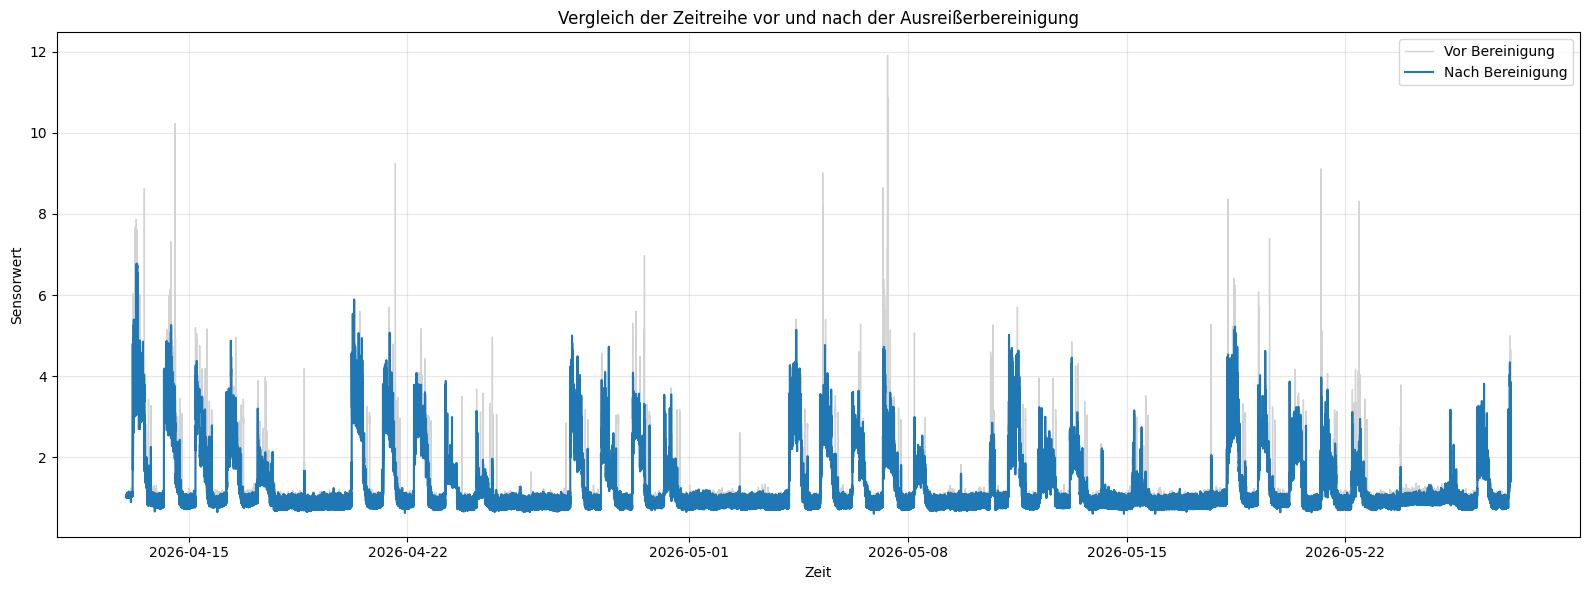

In [ ]:
# Daten laden
df_filtered, df_unfiltered = load_data_variants()

plt.figure(figsize=(16,6))

plt.plot(
    df_unfiltered["timestamp"],
    df_unfiltered["value"],
    color="lightgray",
    linewidth=1,
    label="Vor Bereinigung"
)

plt.plot(
    df_filtered["timestamp"],
    df_filtered["value"],
    color="tab:blue",
    linewidth=1.5,
    label="Nach Bereinigung"
)

plt.title("Vergleich der Zeitreihe vor und nach der Ausreißerbereinigung")
plt.xlabel("Zeit")
plt.ylabel("Sensorwert")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Schritt 6: Transformation in 168-Stunden-Wochenvektoren
Eine Woche hat exakt $7 \times 24 = 168$ Stunden. Wir schneiden die kontinuierliche Zeitreihe in wöchentliche Segmente.

**Besonderheit:** Erkennt der Algorithmus einen Feiertag, verschiebt er die Daten dieses Tages virtuell auf den Sonntag (Index für Sonntag), um das geänderte Nutzerverhalten abzubilden.

In [ ]:
def build_weeks(df):
    if df.empty: return []
    df = df.copy() # Lokale Kopie um Warnungen zu vermeiden
    df['iso_year'] = df['timestamp'].dt.isocalendar().year
    df['iso_week'] = df['timestamp'].dt.isocalendar().week
    df['week_id'] = df['iso_year'] * 100 + df['iso_week']

    weeks = []
    for w_id, group in df.groupby('week_id'):
        current = np.zeros(168)
        hourly_group = group.resample('1H', on='timestamp').mean()

        if hourly_group['value'].notna().sum() < 160:
            continue # Ignoriere unvollständige Wochen

        for dt, row in hourly_group.iterrows():
            val = row['value'] if pd.notna(row['value']) else 0.0
            dt_adj = dt
            if is_german_holiday(dt):
                days_from_monday = dt.weekday()
                dt_adj = dt - pd.Timedelta(days=days_from_monday) + pd.Timedelta(days=6) # Mapping auf Sonntag

            idx = dt_adj.weekday() * 24 + dt_adj.hour
            if idx < 168:
                current[idx] = val

        weeks.append((w_id, current))
    return weeks

###Schritt 6.1: Plot Minutenwerte → Stundenaggregation

/tmp/ipykernel_2812/3261929762.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_group = group.resample('1H', on='timestamp').mean()
/tmp/ipykernel_2812/3261929762.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_group = group.resample('1H', on='timestamp').mean()
/tmp/ipykernel_2812/3261929762.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_group = group.resample('1H', on='timestamp').mean()
/tmp/ipykernel_2812/3261929762.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_group = group.resample('1H', on='timestamp').mean()
/tmp/ipykernel_2812/3261929762.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_group = group.resample('1H', on='timestamp').mean()
/tmp/ipykernel_

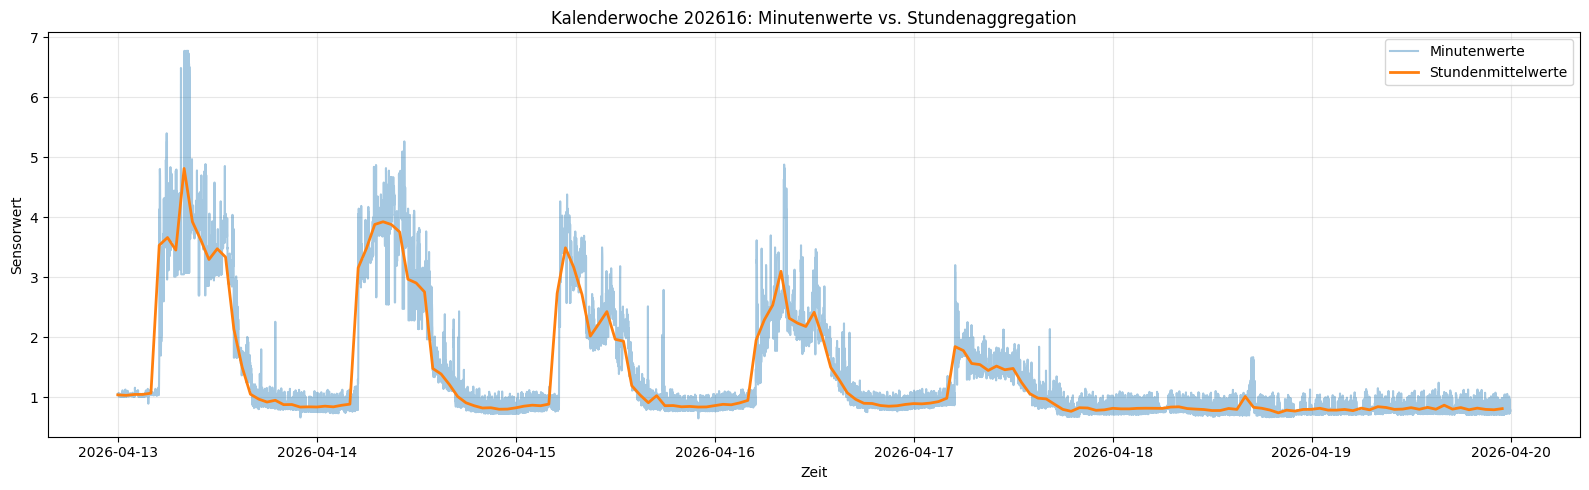

In [ ]:
weeks = build_weeks(df_filtered)

week_id = weeks[0][0]

tmp = df_filtered.copy()
tmp["iso_year"] = tmp["timestamp"].dt.isocalendar().year
tmp["iso_week"] = tmp["timestamp"].dt.isocalendar().week
tmp["week_id"] = tmp["iso_year"] * 100 + tmp["iso_week"]

week_df = tmp[tmp["week_id"] == week_id]

hourly = week_df.resample(
    "1H",
    on="timestamp"
).mean(numeric_only=True)

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(
    week_df["timestamp"],
    week_df["value"],
    alpha=0.4,
    label="Minutenwerte"
)

ax.plot(
    hourly.index,
    hourly["value"],
    linewidth=2,
    label="Stundenmittelwerte"
)

ax.set_title(f"Kalenderwoche {week_id}: Minutenwerte vs. Stundenaggregation")
ax.set_xlabel("Zeit")
ax.set_ylabel("Sensorwert")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2812/3008865491.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_axis = pd.date_range(start="2026-06-01", periods=168, freq="H")


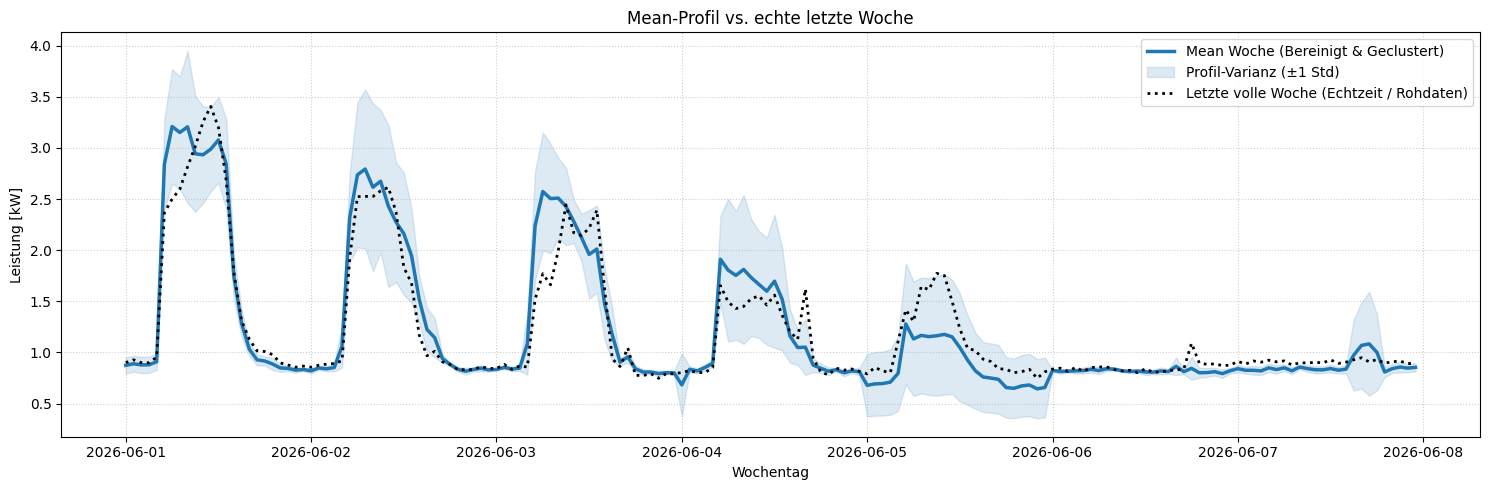

In [ ]:
# --- Daten für das Plotting vorbereiten ---

# Die letzte Woche in der Liste (Index -1) ist die aktuellste
w_id_last, reference_week_raw = weeks[-1]

# Berechnen des Mean-Profil aus allen Wochen
all_week_data = np.array([w[1] for w in weeks])
mean_week = np.mean(all_week_data, axis=0)
std_week = np.std(all_week_data, axis=0)

time_axis = pd.date_range(start="2026-06-01", periods=168, freq="H")

fig, ax = plt.subplots(figsize=(15, 5))

# =========================
# MEAN WEEK (Modell)
# =========================
ax.plot(
    time_axis,
    mean_week,
    label="Mean Woche (Bereinigt & Geclustert)",
    color="#1f77b4",
    linewidth=2.5
)

ax.fill_between(
    time_axis,
    np.maximum(0, mean_week - std_week),
    mean_week + std_week,
    color="#1f77b4",
    alpha=0.15,
    label="Profil-Varianz (±1 Std)"
)

# =========================
# REAL WEEK (letzte echte Woche)
# =========================
ax.plot(
    time_axis,
    reference_week_raw,
    label="Letzte volle Woche (Echtzeit / Rohdaten)",
    color="black",
    linestyle=":",
    linewidth=2
)

# =========================
# FORMATTING
# =========================
ax.set_title("Mean-Profil vs. echte letzte Woche")
ax.set_ylabel("Leistung [kW]")
ax.set_xlabel("Wochentag")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Schritt 8: Bestimmung der Modellgüte (Fehlermaße)

Um die Genauigkeit unserer Prognose bzw. die Qualität des Lastgang-Modells zu bewerten, nutzen wir drei gängige statistische Fehlermaße. Diese ermöglichen eine objektive Quantifizierung der Abweichung zwischen Modell und Realität.

---

### 1. NRMSE (Normalized Root Mean Square Error)

Der NRMSE setzt den quadratischen Mittelwert der Fehler in Bezug zum Wertebereich der Daten. Dadurch ist der Fehler unabhängig von der Skalierung (z. B. kW).

$$
NRMSE = \frac{\sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}}{y_{max} - y_{min}}
$$

---

### 2. MAPE (Mean Absolute Percentage Error)

Der MAPE beschreibt den durchschnittlichen prozentualen Fehler. Er ist besonders gut interpretierbar, da er die Abweichung in Prozent angibt.

$$
MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

---

### 3. R² (Bestimmtheitsmaß)

Das Bestimmtheitsmaß $R^2$ beschreibt, welcher Anteil der Varianz der Daten durch das Modell erklärt wird. Werte nahe 1 deuten auf eine hohe Übereinstimmung hin.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

---

## Interpretation

- **NRMSE** → skalierungsunabhängige Fehlergröße  
- **MAPE** → intuitive prozentuale Abweichung  
- **R²** → Güte der Varianz-Erklärung durch das Modell  

Diese drei Kennzahlen ergänzen sich und sollten gemeinsam betrachtet werden, um die Modellgüte zuverlässig zu bewerten.

### Schritt 7: Vergleich mit realen Messwerten
Wir führen nun alle Schritte zusammen. Als Benchmark plotten wir zusätzlich die letzte verfügbare Echtzeit-Woche (Rohdaten in schwarz gepunktet) über die generierten Profile, um zu sehen, wie gut unsere mathematischen Repräsentanten die Realität abbilden.

In [ ]:
# --- FEHLERANALYSE ZUM PLOT ---

# Stelle sicher, dass beide Datensätze numpy-Arrays sind (ggf. Index ablegen)
y_true = np.array(reference_week_raw)
y_pred = np.array(mean_week)

# NRMSE, MAPE und R² berechnen
mse = np.mean((y_true - y_pred)**2)
nrmse = np.sqrt(mse) / (y_true.max() - y_true.min())
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
ss_res = np.sum((y_true - y_pred)**2)
ss_tot = np.sum((y_true - np.mean(y_true))**2)
r2 = 1 - (ss_res / ss_tot)

# Ergebnisse als Text in den Plot oder ins Terminal
print("--- Modellgüte des Mean-Profils ---")
print(f"NRMSE: {nrmse:.4f}")
print(f"MAPE:  {mape:.2f} %")
print(f"R²:    {r2:.4f}")

# Optional: Die Werte direkt in den Plot schreiben
stats_text = f"NRMSE: {nrmse:.2f}\nMAPE: {mape:.1f}%\nR²: {r2:.2f}"


--- Modellgüte des Mean-Profils ---
NRMSE: 0.0804
MAPE:  10.07 %
R²:    0.8730
